In [12]:
import matplotlib.pyplot as plt
import tifffile
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.transforms as mtransforms


import cmcrameri.cm as cm

In [2]:
def gaussian(x, amplitude, mean, std_dev, offset):
    return -amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2)) + offset

In [3]:
def find_min_brightness(x_data, y_data, start_index, end_index):
    mask = (x_data >= start_index) & (x_data <= end_index)
    x_fit = x_data[mask]
    y_fit = y_data[mask]

    guess_amp = np.min(y_fit)
    guess_center = x_fit[np.argmin(y_fit)]
    guess_sigma = 10.0 
    guess_offset = 0

    initial_guess = [guess_amp, guess_center, guess_sigma, guess_offset]
    popt, cov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess)

    return popt, cov, x_fit, y_fit

In [4]:
# load preshot images - alignment target
frame1_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_1.tiff')
frame2_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_2.tiff')
frame3_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_3.tiff')
frame4_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_4.tiff')
frame5_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_5.tiff')
frame6_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_6.tiff')
frame7_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_7.tiff')
frame8_alignment = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/Alignment_target/Frame_8.tiff')

# no alignment target
frame1_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_1.tiff')
frame2_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_2.tiff')
frame3_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_3.tiff')
frame4_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_4.tiff')
frame5_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_5.tiff')
frame6_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_6.tiff')
frame7_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_7.tiff')
frame8_bg = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/preshot/No_alignment_target/Frame_8.tiff')

# shot images
shot_1 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_1.tiff')
shot_2 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_2.tiff')
shot_3 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_3.tiff')
shot_4 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_4.tiff')
shot_5 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_5.tiff')
shot_6 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_6.tiff')
shot_7 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_7.tiff')
shot_8 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_8.tiff')

In [5]:
align_im = [frame1_alignment, frame2_alignment, frame3_alignment, frame4_alignment, frame5_alignment, frame6_alignment, frame7_alignment, frame8_alignment]

for i in range(8):
    plt.title(f'Pre Shot with Alignment Target (Frame {i+1})')
    plt.imshow(align_im[i], cmap = 'grey') 
    plt.savefig(f'shadowgraphy_images/align_frame{i+1}', bbox_inches = 'tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

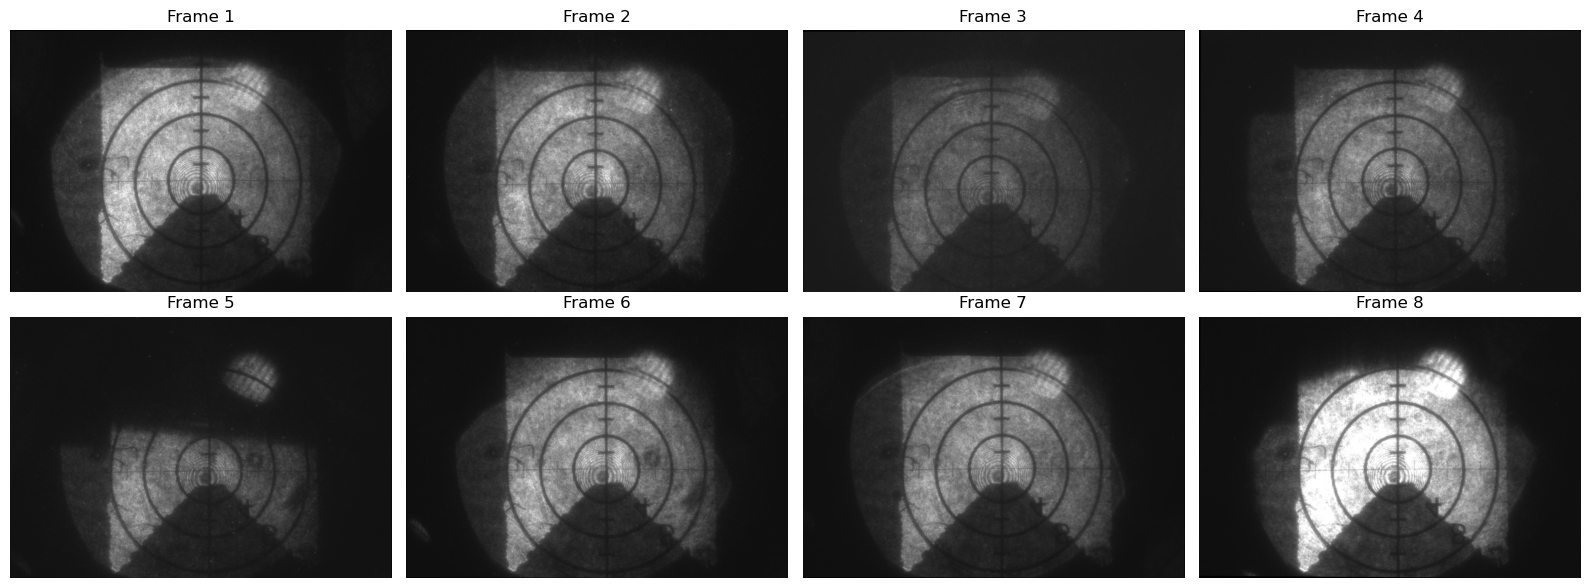

In [6]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(align_im[i], cmap = 'gray')
    axes[i].set_title(f"Frame {i+1}")
    axes[i].set_axis_off() 

plt.tight_layout()  # Prevents overlapping labels
plt.savefig('analysis/frames/preshot_alignment')

In [7]:
bg_im = [frame1_bg, frame2_bg, frame3_bg, frame4_bg, frame5_bg, frame6_bg, frame7_bg, frame8_bg]

for i in range(8):
    plt.title(f'Pre Shot without Alignment Target (Frame {i+1})')
    plt.imshow(bg_im[i], cmap = 'grey') 
    plt.savefig(f'shadowgraphy_images/bg_frame{i+1}', bbox_inches = 'tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

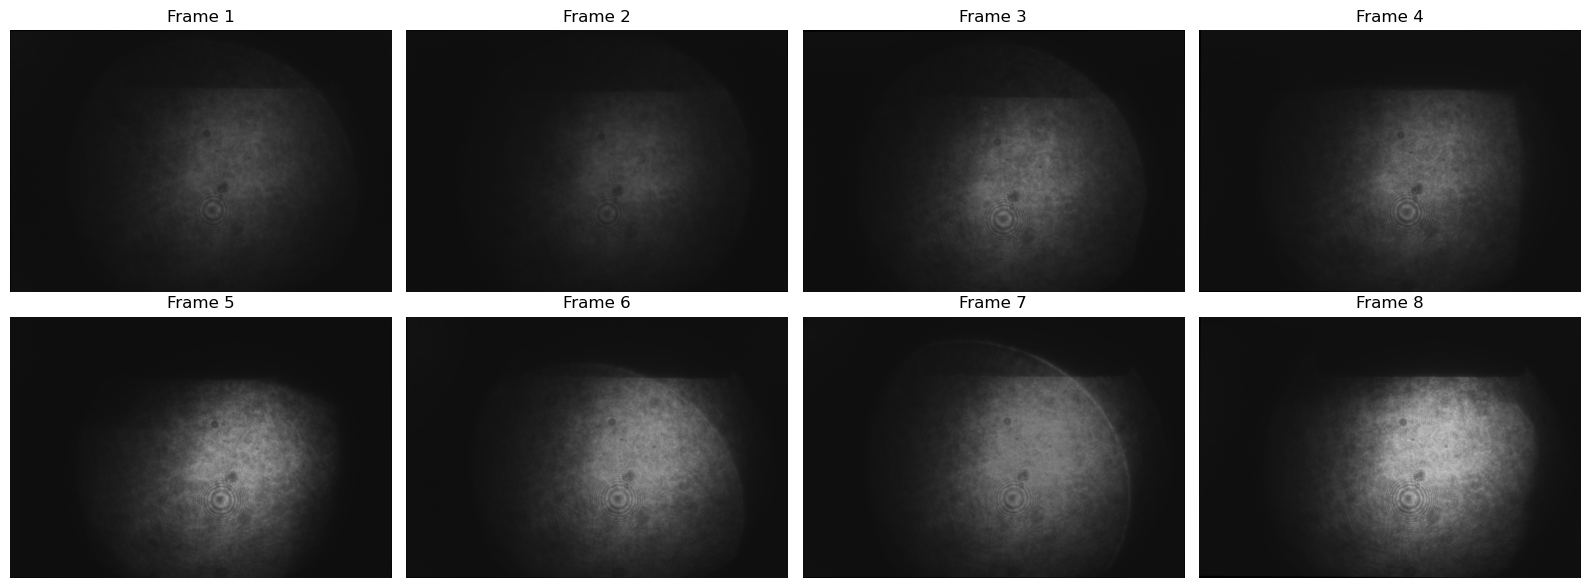

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(bg_im[i], cmap = 'gray')
    axes[i].set_title(f"Frame {i+1}")
    axes[i].set_axis_off() 

plt.tight_layout()  # Prevents overlapping labels
plt.savefig('analysis/frames/preshot_bg')

In [9]:
shot_im = [shot_1, shot_2, shot_3, shot_4, shot_5, shot_6, shot_7, shot_8]
times = [3290, 3295, 3305, 3310, 3315, 3320, 3325, 3330]

for i in range(8):
    plt.title(f't = {times[i]}')
    plt.imshow(shot_im[i], cmap = 'grey') 
    plt.savefig(f'shadowgraphy_images/shot_{i+1}', bbox_inches = 'tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

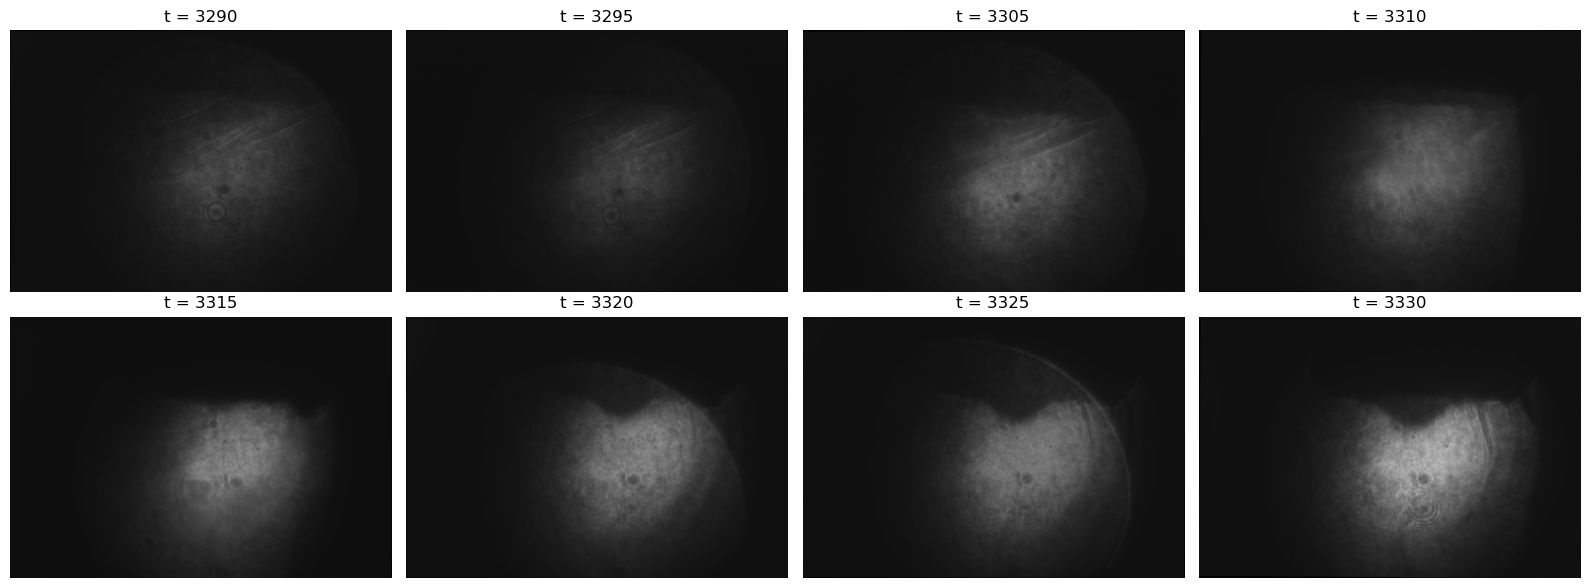

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()

for i in range(8):
    axes[i].imshow(shot_im[i], cmap = 'gray')
    axes[i].set_title(f"t = {times[i]}")
    axes[i].set_axis_off() 

plt.tight_layout()  # Prevents overlapping labels
plt.savefig('analysis/frames/shot')

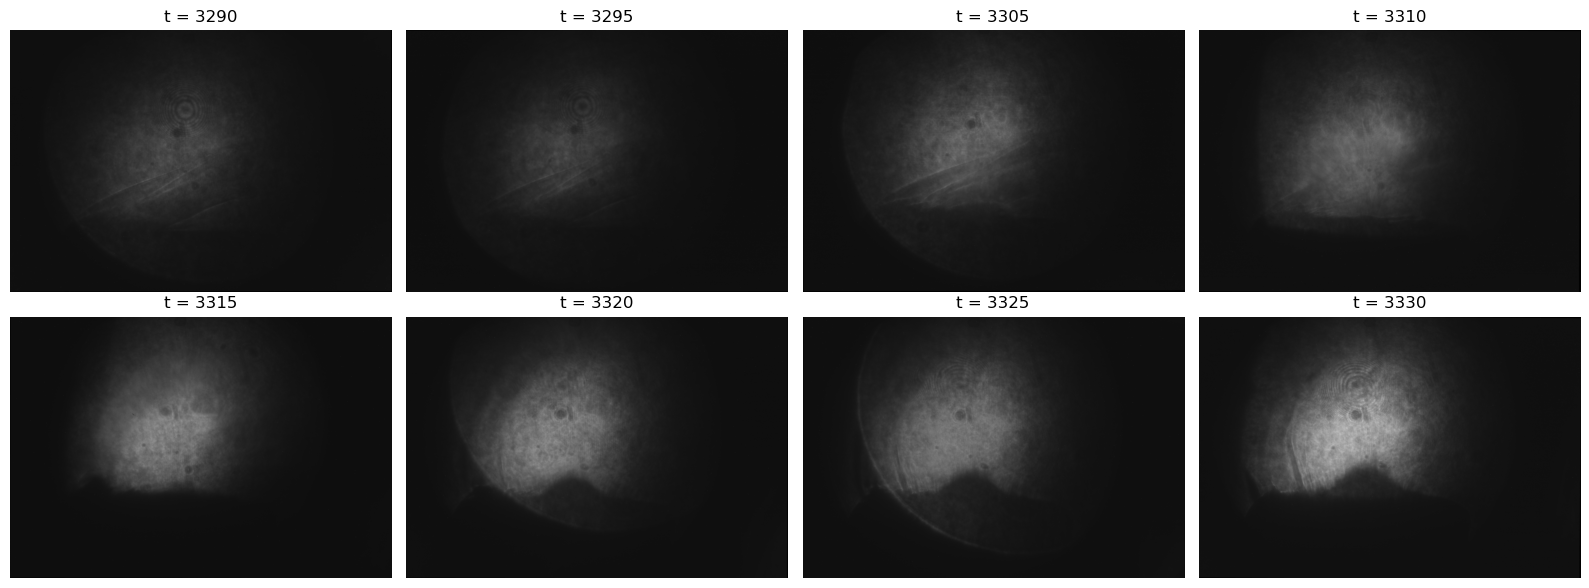

In [16]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 6))
axes = axes.flatten()
# tr = mtransforms.Affine2D().rotate_deg(180)

for i in range(8):
    axes[i].imshow(np.rot90(shot_im[i],2), cmap = 'gray')
    axes[i].set_title(f"t = {times[i]}")
    axes[i].set_axis_off() 

plt.tight_layout()  # Prevents overlapping labels
plt.savefig('analysis/frames/shot_rot')

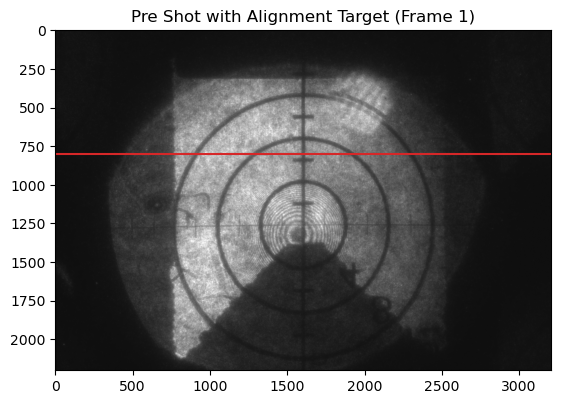

In [17]:
row_index = 800 # 1575

fig, ax = plt.subplots()

plt.title('Pre Shot with Alignment Target (Frame 1)')
plt.imshow(frame1_alignment, cmap = 'grey')
plt.axhline(row_index, color = 'tab:red')

plt.savefig(f'analysis/calibration/h_lineout_{row_index}_positions', bbox_inches = 'tight')

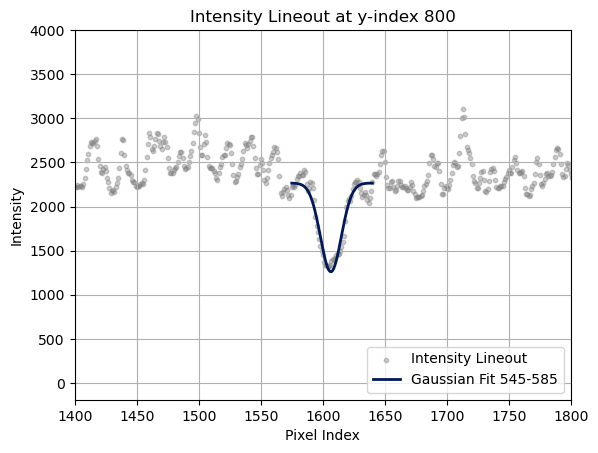

In [18]:
y_data = frame1_alignment[row_index, :].astype(float)
x_data = np.arange(len(y_data))
plt.scatter(x_data, y_data, color='gray', alpha=0.4, label='Intensity Lineout', s=10)

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 1575, end_index = 1640)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 545-585', color = cm.batlowS(0))
middle_ch = x_detailed[np.argmin(gaussian(x_detailed, *popt))]

plt.title(f'Intensity Lineout at y-index {row_index}')
plt.xlim(1400,1800)
plt.xlabel('Pixel Index')
plt.ylabel('Intensity')
plt.legend(loc = 4)
plt.grid(True)
plt.savefig(f'analysis/calibration/h_lineout_{row_index}', bbox_inches = 'tight')

1575


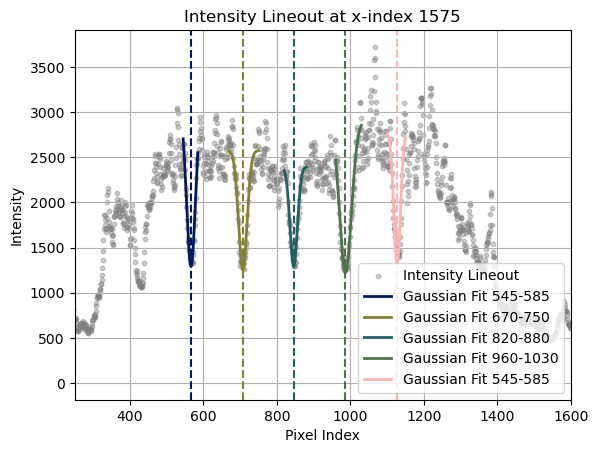

In [19]:
# line_index = int(np.round(middle_ch, decimals = 0)) # 1575
line_index = 1575
print(line_index)
minimums_offc = []
colors = [cm.batlowS(i) for i in range(8)]
colors = [colors[0], colors[2], colors[3],colors[5], colors[7]]

y_data = frame1_alignment[:, line_index].astype(float)
x_data = np.arange(len(y_data))
plt.scatter(x_data, y_data, color='gray', alpha=0.4, label='Intensity Lineout', s=10)

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 545, end_index = 585)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 545-585', color = colors[0])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_offc.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 670, end_index = 750)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 670-750', color = colors[1])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_offc.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 820, end_index = 880)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 820-880', color = colors[2])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_offc.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 960, end_index = 1030)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 960-1030', color = colors[3])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_offc.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 1100, end_index = 1150)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 545-585', color = colors[4])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_offc.append(x_detailed[curve_min])

for m in range(len(minimums_offc)):
    plt.axvline(minimums_offc[m], linestyle='--', color = colors[m])

plt.title(f'Intensity Lineout at x-index {line_index}')
plt.xlim(250,1600)
plt.xlabel('Pixel Index')
plt.ylabel('Intensity')
plt.legend(loc = 4)
plt.grid(True)
plt.savefig(f'analysis/calibration/v_lineout_{line_index}', bbox_inches = 'tight')

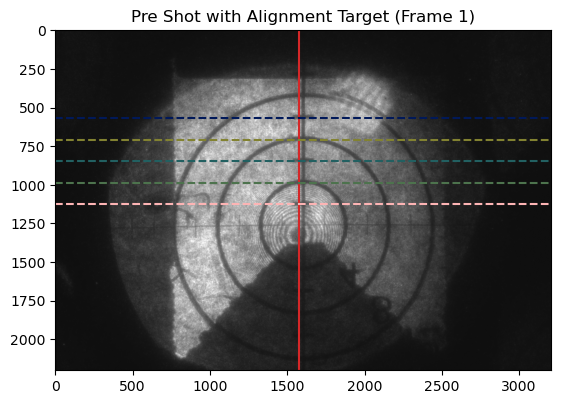

In [20]:
fig, ax = plt.subplots()

plt.title('Pre Shot with Alignment Target (Frame 1)')
plt.imshow(frame1_alignment, cmap = 'grey')
plt.axvline(line_index, color = 'tab:red')

for m in range(len(minimums_offc)):
    plt.axhline(minimums_offc[m], linestyle='--', color = colors[m])

plt.savefig(f'analysis/calibration/v_lineout_{line_index}_positions', bbox_inches = 'tight')

1607


<Figure size 640x480 with 0 Axes>

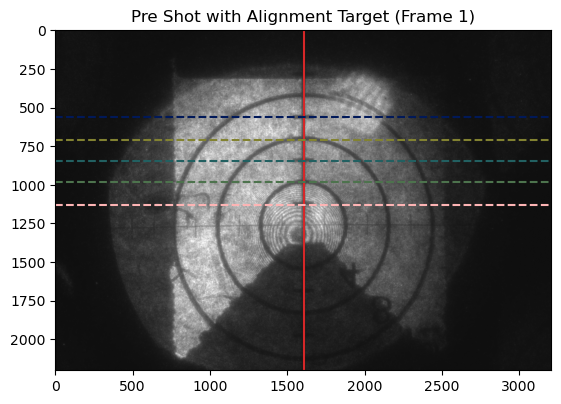

In [21]:
line_index = int(np.round(middle_ch, decimals = 0)) # 1575
# line_index = 1575
print(line_index)
minimums_center = []
colors = [cm.batlowS(i) for i in range(8)]
colors = [colors[0], colors[2], colors[3],colors[5], colors[7]]

y_data = frame1_alignment[:, line_index].astype(float)
x_data = np.arange(len(y_data))
plt.scatter(x_data, y_data, color='gray', alpha=0.4, label='Intensity Lineout', s=10)

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 545, end_index = 585)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 545-585', color = colors[0])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_center.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 670, end_index = 750)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 670-750', color = colors[1])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_center.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 820, end_index = 880)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 820-880', color = colors[2])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_center.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 960, end_index = 1030)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 960-1030', color = colors[3])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_center.append(x_detailed[curve_min])

popt, cov, x_fit, y_fit = find_min_brightness(x_data, y_data, start_index = 1100, end_index = 1150)
x_detailed = np.linspace(x_fit.min(), x_fit.max(), 500)
plt.plot(x_detailed, gaussian(x_detailed, *popt), linewidth=2, label='Gaussian Fit 545-585', color = colors[4])
curve_min = np.argmin(gaussian(x_detailed, *popt))
minimums_center.append(x_detailed[curve_min])

for m in range(len(minimums_center)):
    plt.axvline(minimums_center[m], linestyle='--', color = colors[m])

plt.title(f'Intensity Lineout at x-index {line_index}')
plt.xlim(250,1600)
plt.xlabel('Pixel Index')
plt.ylabel('Intensity')
plt.legend(loc = 4)
plt.grid(True)
plt.savefig(f'analysis/v_lineout_{line_index}', bbox_inches = 'tight')
plt.clf()

fig, ax = plt.subplots()

plt.title('Pre Shot with Alignment Target (Frame 1)')
plt.imshow(frame1_alignment, cmap = 'grey')
plt.axvline(line_index, color = 'tab:red')

for m in range(len(minimums_center)):
    plt.axhline(minimums_center[m], linestyle='--', color = colors[m])

plt.savefig(f'analysis/calibration/v_lineout_{line_index}_positions', bbox_inches = 'tight')

In [22]:
print('Minimums (exact center):', minimums_center)
print('Minimums (off center):', minimums_offc)

Minimums (exact center): [np.float64(561.9138276553106), np.float64(709.1182364729459), np.float64(847.4148296593187), np.float64(984.2685370741483), np.float64(1131.7635270541082)]
Minimums (off center): [np.float64(566.1623246492986), np.float64(707.3547094188377), np.float64(845.8517034068136), np.float64(986.7935871743487), np.float64(1127.254509018036)]


In [25]:
spacings_mid = []
distances_mid = []
xcoords = []
ycoords = []
for i in range(len(minimums_center)):
    j = i+1
    while j < 5:
        dist = minimums_center[i]-minimums_center[j]
        distances_mid.append(-dist)
        spac = np.abs(dist/(i-j))
        spacings_mid.append(spac)
        xcoords.append(i)
        ycoords.append(j)
        j+=1

tab = {
    'x': xcoords,
    'y': ycoords,
    'distance': distances_mid,
    'spacing': spacings_mid
}

spac_table_mid = pd.DataFrame(tab)
spac_table_mid = spac_table_mid.round(2)

spac_table_mid.to_csv('analysis/spacings_mid.csv', index=False)

print(spac_table_mid)

   x  y  distance  spacing
0  0  1    147.20   147.20
1  0  2    285.50   142.75
2  0  3    422.35   140.78
3  0  4    569.85   142.46
4  1  2    138.30   138.30
5  1  3    275.15   137.58
6  1  4    422.65   140.88
7  2  3    136.85   136.85
8  2  4    284.35   142.17
9  3  4    147.49   147.49


In [26]:
spacings_off = []
distances_off = []
xcoords = []
ycoords = []
for i in range(len(minimums_offc)):
    j = i+1
    while j < 5:
        dist = minimums_offc[i]-minimums_offc[j]
        distances_off.append(-dist)
        spac = np.abs(dist/(i-j))
        spacings_off.append(spac)
        xcoords.append(i)
        ycoords.append(j)
        j+=1

tab = {
    'x': xcoords,
    'y': ycoords,
    'distance': distances_off,
    'spacing': spacings_off
}

spac_table_off = pd.DataFrame(tab)
spac_table_off = spac_table_off.round(2)

spac_table_off.to_csv('analysis/spacings_off.csv', index=False)

print(spac_table_off)

   x  y  distance  spacing
0  0  1    141.19   141.19
1  0  2    279.69   139.84
2  0  3    420.63   140.21
3  0  4    561.09   140.27
4  1  2    138.50   138.50
5  1  3    279.44   139.72
6  1  4    419.90   139.97
7  2  3    140.94   140.94
8  2  4    281.40   140.70
9  3  4    140.46   140.46


In [65]:
avg_spacing = np.average(spacings)
print(avg_spacing)

px_to_mm = 1/(avg_spacing*2)

extent_x = frame1_alignment.shape[1] * px_to_mm
extent_y = frame1_alignment.shape[0] * px_to_mm
ext=[-extent_x/2, extent_x/2, -extent_y/2, extent_y/2]

141.64787909151636


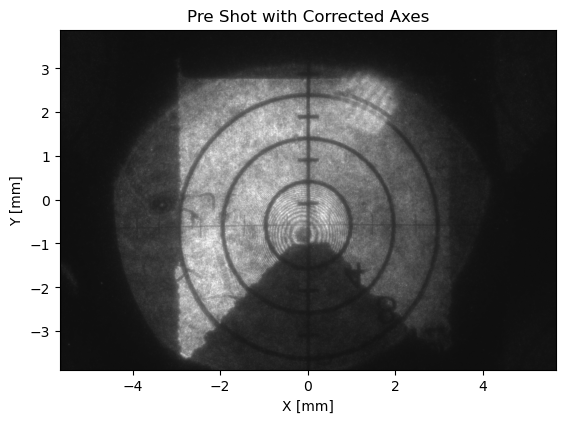

In [66]:
fig, ax = plt.subplots()

plt.title('Pre Shot with Corrected Axes')
plt.imshow(frame1_alignment, cmap = 'grey', extent=ext)

plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')

plt.savefig(f'analysis/alignment_axmm', bbox_inches = 'tight')

In [13]:
# load shot images
frame1 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_1.tiff')
frame2 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_2.tiff')
frame3 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_3.tiff')
frame4 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_4.tiff')
frame5 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_5.tiff')
frame6 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_6.tiff')
frame7 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_7.tiff')
frame8 = tifffile.imread('LIONZ_zshot3_raw/shadowgraphy/shot/Frame_8.tiff')

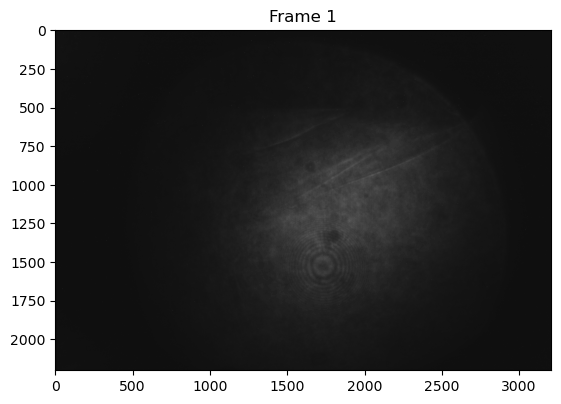

In [9]:
plt.title('Frame 1')
plt.imshow(frame1, cmap = 'grey')